In [23]:
import pandas
import os

df = pandas.read_csv(os.path.join('eval_result', 'summary.csv'), sep=';')

In [24]:
df.fillna(0.5, inplace=True)
df

,MODEL,TC1,TC2,TC3,TC4,TC5,TC6,TC7,TC8,TC9,TC10,TC11,TC12,TC13,TC14
0,qwen:1.8b,0.20,0.50,0.2,0.1,1,?,0.326,0.2,?,0.90,?,0.90,0.0,0.0
1,qwen:4b,0.80,0.80,0.5,1.0,?,?,1.000,1.0,?,1.00,?,1.00,1.0,0.0
2,qwen2.5:0.5b,1.00,0.80,0.9,0.8,0.7,?,0.200,0.8,?,0.00,?,1.00,0.8,0.8
3,qwen2.5:1.5b,1.00,0.38,1.0,1.0,0.9,?,1.000,1.0,?,0.00,0.7,1.00,1.0,1.0
4,qwen2.5:3b,0.90,0.80,0.9,1.0,0.9625,?,1.000,0.8,?,1.00,1,1.00,1.0,0.5
5,qwen2.5-coder:1.5b,0.80,1.00,0.9,0.9,0.8,?,0.400,0.7,?,1.00,0.9,1.00,1.0,1.0
6,llama3.2:3b,0.95,0.80,0.5,1.0,0.9,?,1.000,1.0,?,0.95,1,1.00,0.9,0.9
7,mistral:7b,1.00,1.00,0.8,1.0,1,?,0.200,0.8,?,1.00,1,1.00,0.6,0.8
8,mistrallite:7b,1.00,0.60,1.0,0.9,0.9,0,1.000,1.0,?,1.00,1,1.00,1.0,0.7
9,codegemma:2b,0.00,0.80,0.9,0.8,?,?,0.600,0.5,?,0.00,0.5,1.00,0.5,0.5


In [25]:
models = ['qwen:1.8b', 'qwen:4b', 'qwen2.5:0.5b', 'qwen2.5:1.5b',
       'qwen2.5:3b', 'qwen2.5-coder:1.5b', 'llama3.2:3b', 'codegemma:2b', 'deepseek-r1:1.5b']

In [26]:
import math

def is_float(value):
    try:
        float(value)
        # if (math.isnan(float(value))):
        #     return False
        return True
    except ValueError:
        return False

avg_list = []

def sum_eval(eval: list[float]):
    sum = 0
    for x in eval:
        if is_float(x):
            sum += float(x)
    return sum

for model in models:
    df_model = df[df['MODEL'] == model]
    del df_model['MODEL']
    eval = df_model.values[0]
    eval = [float(x) for x in eval if is_float(x)]
    # print(eval)
    # print(model, eval)
    avg_list.append((model, (sum_eval(eval) / len(eval))))
    
# print(avg_list)
# for x in avg_list:
#     print(x)

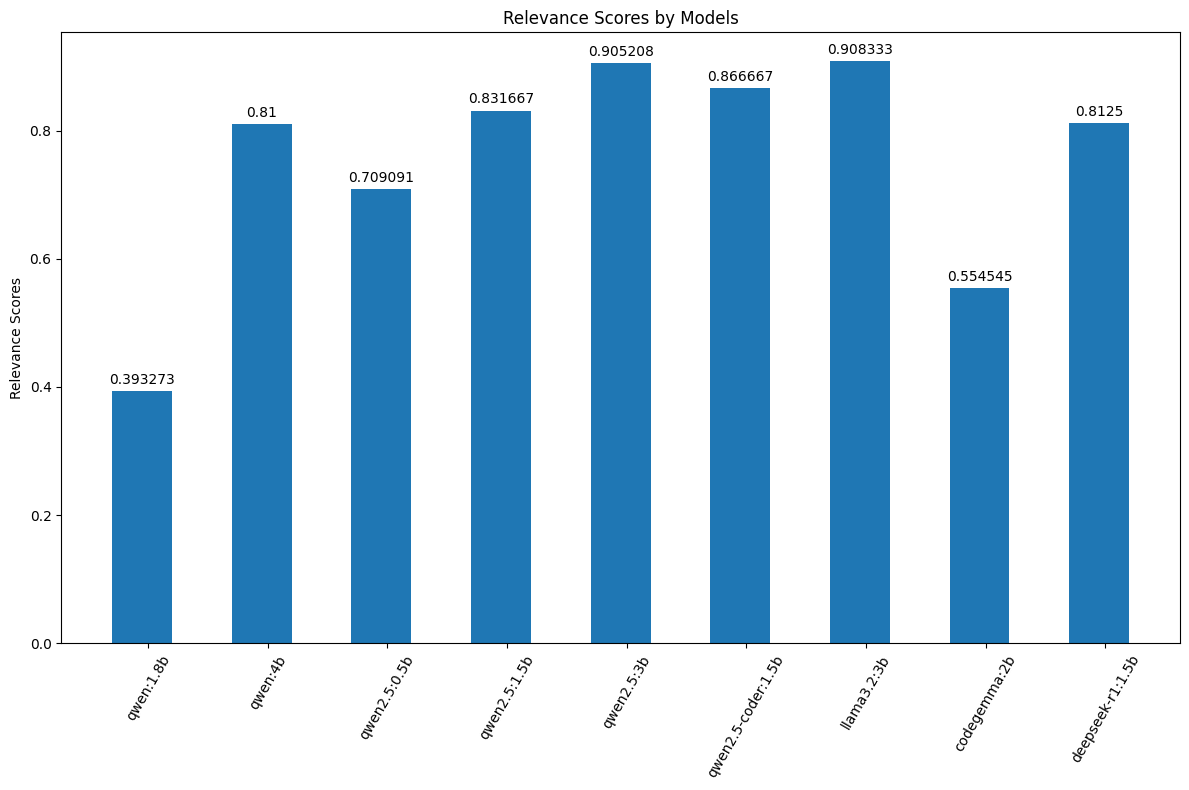

In [31]:
# Plot the result on a bar chart, each model has different color

import matplotlib.pyplot as plt
import numpy as np

labels = [x[0] for x in avg_list]
values = [x[1] for x in avg_list]

x = np.arange(len(labels))  # the label locations
width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 8))
rects = ax.bar(x - width/2, values, width*5, label='Scores')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Relevance Scores')
ax.set_title('Relevance Scores by Models')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60)
# ax.legend()

ax.bar_label(rects, padding=3)

fig.tight_layout()

plt.show()